# Yolov1 

## 1.環境設定與套件安裝

In [1]:
import torch
print(f'PyTorch 版本: {torch.__version__}')
print(f'CUDA 可用: {torch.cuda.is_available()}')

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch 版本: 2.8.0+cu126
CUDA 可用: True
GPU: NVIDIA GeForce RTX 4060


In [2]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

## 2.資料集下載與標註 : Pascal VOC 2007

### voc 2007
- 20個物件類別
- 標註格式為 XML
- 訓練 2501 張，測試 4952 張

#### 資料夾結構

VOCdevkit/VOC2007/ <br>
|－Annotations/  <-XML標註 <br>
|－ImageSets/Main/ <-train.txt / val.txt / test.txt <br>
|__JEPGImages/ <-原始圖片 <br>

使用VOC 2007  (共20類)

In [ ]:
# ============================= 這裡要打code =============================











# ============================= 這裡要打code =============================

資料集存在，略過下載步驟!


![POSCAL datasets](assets\PASCAL.png)

Step1. 定義20個類別

In [ ]:
# ============================= 這裡要打code =============================











# ============================= 這裡要打code =============================

類別數量: 20
類別列表: {'aeroplane': 0, 'bicycle': 1, 'bird': 2, 'boat': 3, 'bottle': 4, 'bus': 5, 'car': 6, 'cat': 7, 'chair': 8, 'cow': 9, 'diningtable': 10, 'dog': 11, 'horse': 12, 'motorbike': 13, 'person': 14, 'pottedplant': 15, 'sheep': 16, 'sofa': 17, 'train': 18, 'tvmonitor': 19}


### 解析xml標註

其中一個標註檔案的範例：<br>
```<annotation>
	<folder>VOC2007</folder>
	<filename>000002.jpg</filename>
	<source>
		<database>The VOC2007 Database</database>
		<annotation>PASCAL VOC2007</annotation>
		<image>flickr</image>
		<flickrid>329145082</flickrid>
	</source>
	<owner>
		<flickrid>hiromori2</flickrid>
		<name>Hiroyuki Mori</name>
	</owner>
	<size>
		<width>335</width>
		<height>500</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>train</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>139</xmin>
			<ymin>200</ymin>
			<xmax>207</xmax>
			<ymax>301</ymax>
		</bndbox>
	</object>
</annotation>```

資料集標記 <br>
Annotation 為 XML 的格式

In [ ]:
# ============================= 這裡要打code =============================











# ============================= 這裡要打code =============================

範例標注檔: 000009.xml
標注數量: 4
格式 (class_idx, x1, y1, x2, y2, W, H)
- (12, 69.0, 172.0, 270.0, 330.0, 500, 375)
- (14, 150.0, 141.0, 229.0, 284.0, 500, 375)
- (14, 285.0, 201.0, 327.0, 331.0, 500, 375)
- (14, 258.0, 198.0, 297.0, 329.0, 500, 375)


## 3.YOLOv1 標籤編碼 (定義Yolo格式tensor)

#### Grid Cell 預測

圖片會分割成 SxS = 7x7的格子，每個格子負責預測:
- B=2個Bounding Box: (x,y,w,h,confidence)
- c=20個類別機率

$$\text{輸出 Tensor 型狀} = S \times S \times (B \times 5 + C) = 7 \times 7 \times 30 $$

#### 座標編碼
| 變數 | 意義 | 範圍 |
|------|------|------|
| x, y | 物體中心相對於所在 cell 偏移 | [0,1]
| w, h | 物體寬高相對於整張圖比例 | [0,1]
| conf | 該格有物體的信心度 | [0,1]

yolo格式

In [ ]:
# ============================= 這裡要打code =============================











# ============================= 這裡要打code =============================

輸出 Target 形狀: [7, 7, 30]


## 4.資料增強

yolov1論文使用:
- 隨機縮放(正負20%)
- 隨機水平翻轉
- HSV色彩空間調整
- 歸一化[0,1]

In [ ]:
IMG_SIZE = 448
class VOCDataset(Dataset):
    def __init__(self, voc_dir, split='train', img_size=448, augment=True):
        self.voc_dir = Path(voc_dir)
        self.img_size = img_size
        self.augment = augment

        split_file = self.voc_dir / 'ImageSets' / 'Main' / f'{split}.txt'
        with open(split_file) as f:
            self.ids = [line.strip() for line in f if line.strip()]
        self.base_transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(
                mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]
            )
        ])

        print(f"[{split}] 載入 {len(self.ids)} 張圖片")
    
    def __len__(self):
        return len(self.ids)
    
    def __getitem__(self, idx):
        img_id = self.ids[idx]

        # 讀取圖片
        img_path = self.voc_dir / 'JPEGImages' / f'{img_id}.jpg'
        image = Image.open(img_path).convert('RGB')

        # 讀取標註
        xml_path = self.voc_dir / 'Annotations' / f'{img_id}.xml'
        boxes = parse_voc_xml(xml_path)

        # 資料增強
        if self.augment and torch.rand(1).item() > 0.5:
            image = T.functional.hflip(image)  
            orig_W = image.width
            flipped = []
            for cls_idx, x1, y1, x2, y2, W, H in boxes:
                new_x1 = W-x2
                new_x2 = W-x1
                flipped.append((cls_idx, new_x1, y1, new_x2, y2, W, H))
            boxes = flipped
        
        image = self.base_transform(image)
        target = encode_yolo_label(boxes, self.img_size)

        return image, target


In [8]:
train_dataset = VOCDataset(VOC_DIR, split='train', augment=True)
val_dataset   = VOCDataset(VOC_DIR, split='val',   augment=False)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f'\n Train batches: {len(train_loader)}')
print(f' Val   batches: {len(val_loader)}')


[train] 載入 2501 張圖片
[val] 載入 2510 張圖片

 Train batches: 157
 Val   batches: 157


## 5.YOLOv1 網路主架構

Input [448x448x3]<br> -> 24 x Conv Layer (Conv-BN-LeakyReLU) ..有些會有maxpooling <br>-> Flatten<br> -> FC<br> -> FC

In [ ]:
# ============================= 這裡要打code =============================











# ============================= 這裡要打code =============================

In [10]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [11]:
model  = YOLOv1(S=S, B=B, C=C).to(DEVICE)

# 測試前向傳播
with torch.no_grad():
    dummy = torch.randn(2, 3, 448, 448).to(DEVICE)
    out = model(dummy)
    print(f'\n輸入形狀:  {dummy.shape}')
    print(f'輸出形狀:  {out.shape}  # [B, S, S, B*5+C]')


輸入形狀:  torch.Size([2, 3, 448, 448])
輸出形狀:  torch.Size([2, 7, 7, 30])  # [B, S, S, B*5+C]


## 6.Loss 函數 (YOLO版本)

IOU 計算（Intersection over Union）

定義IOU

In [ ]:
# ============================= 這裡要打code =============================











# ============================= 這裡要打code =============================

YOLOv1 Loss

![YOLO Loss](assets\YOLO_Loss.png)

Loss

In [ ]:
# ============================= 這裡要打code =============================











# ============================= 這裡要打code =============================

Loss 函數定義完成！


In [14]:
imgs, targets = next(iter(train_loader))
imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)

with torch.no_grad():
    preds = model(imgs)
    print('preds 有 nan:', torch.isnan(preds).any().item())
    print('preds max:', preds.max().item())
    print('preds min:', preds.min().item())
    print('targets 有 nan:', torch.isnan(targets).any().item())

preds 有 nan: False
preds max: 0.990994393825531
preds min: 0.00228642369620502
targets 有 nan: False


## 7.Training 開始

In [ ]:
# ==========================================
# 訓練設定
# ==========================================
EPOCHS     = 30
LR         = 5e-4
WEIGHT_DECAY = 5e-4

optimizer  = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler  = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 25], gamma=0.1)

# 訓練記錄
history = {'train_loss': [], 'val_loss': []}
CKPT_DIR = Path('./checkpoints')
CKPT_DIR.mkdir(exist_ok=True)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    loss_parts = {'coord': 0, 'conf_obj': 0, 'conf_noobj': 0, 'cls': 0}
    
    pbar = tqdm(loader, desc='Training', leave=False)
    for imgs, targets in pbar:
        imgs    = imgs.to(device)
        targets = targets.to(device)
        
        # 前向傳播
        preds = model(imgs)
        loss, parts = criterion(preds, targets)
        
        # 反向傳播
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)  # 梯度裁剪
        optimizer.step()
        
        total_loss += loss.item()
        for k in loss_parts:
            loss_parts[k] += parts[k]
        
        pbar.set_postfix({'loss': f'{loss.item():.3f}'})
    
    n = len(loader)
    return total_loss / n, {k: v / n for k, v in loss_parts.items()}


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    for imgs, targets in loader:
        imgs, targets = imgs.to(device), targets.to(device)
        preds = model(imgs)
        loss, _ = criterion(preds, targets)
        total_loss += loss.item()
    return total_loss / len(loader)


# ==========================================
# 主訓練迴圈
# ==========================================
best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    train_loss, parts = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss          = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    # 儲存最佳模型
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CKPT_DIR / 'yolov1_best.pth')
    
    # 每 5 epoch 顯示一次詳情
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch [{epoch:3d}/{EPOCHS}]  '
              f'Train: {train_loss:.4f}  Val: {val_loss:.4f}  '
              f'LR: {scheduler.get_last_lr()[0]:.2e}')
        print(f'  Loss 拆解 → coord: {parts["coord"]:.3f}  '
              f'conf_obj: {parts["conf_obj"]:.3f}  '
              f'conf_noobj: {parts["conf_noobj"]:.3f}  '
              f'cls: {parts["cls"]:.3f}')

print(f'\n✅ 訓練完成！最佳 Val Loss: {best_val_loss:.4f}')

Epoch [  1/30]  Train: 7.4401  Val: 5.2664  LR: 5.00e-04
  Loss 拆解 → coord: 4.726  conf_obj: 0.068  conf_noobj: 0.094  cls: 2.552


Epoch [  5/30]  Train: 6.4462  Val: 5.2375  LR: 5.00e-04
  Loss 拆解 → coord: 4.218  conf_obj: 0.075  conf_noobj: 0.014  cls: 2.139


Epoch [ 10/30]  Train: 5.6278  Val: 4.3731  LR: 5.00e-04
  Loss 拆解 → coord: 3.479  conf_obj: 0.079  conf_noobj: 0.012  cls: 2.058


Epoch [ 15/30]  Train: 4.9544  Val: 4.2422  LR: 5.00e-05
  Loss 拆解 → coord: 2.812  conf_obj: 0.082  conf_noobj: 0.016  cls: 2.044


Training:  18%|█▊        | 28/157 [00:37<02:46,  1.29s/it, loss=5.078]  

## 8.推論 (含NMS後處理+Decode預測)

1.NMS定義

In [ ]:
# ============================= 這裡要打code =============================











# ============================= 這裡要打code =============================

2.Decode 預測結果

In [ ]:
# ============================= 這裡要打code =============================











# ============================= 這裡要打code =============================

C:\Users\User\AppData\Local\Temp\ipykernel_2504\268090752.py:65: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_2504\268090752.py:65: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


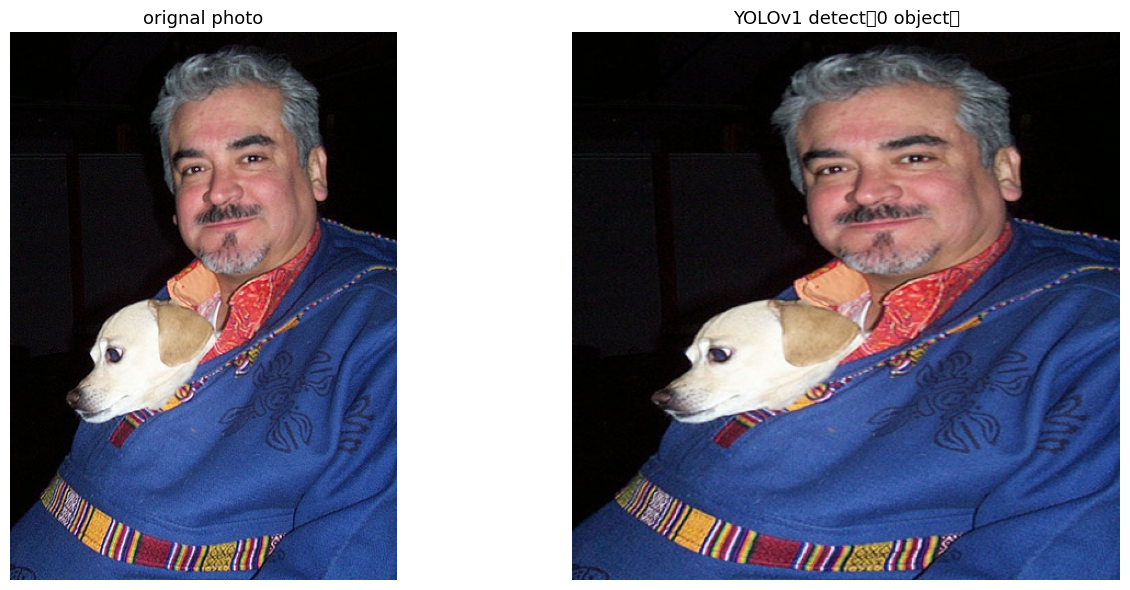

In [ ]:
# ==========================================
# 推論與結果視覺化
# ==========================================
import matplotlib.patches as patches
# 載入最佳模型
model.load_state_dict(torch.load(CKPT_DIR / 'yolov1_best.pth', map_location=DEVICE))
model.eval()

# 顏色 palette（每個類別一個顏色）
np.random.seed(42)
COLORS = np.random.rand(NUM_CLASSES, 3)


def inference_and_visualize(image_path, conf_threshold=0.3, iou_threshold=0.5):
    """
    對單張圖片執行推論並視覺化結果
    """
    # 圖片前處理
    img_orig = Image.open(image_path).convert('RGB')
    transform = T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    img_tensor = transform(img_orig).unsqueeze(0).to(DEVICE)  # [1, 3, 448, 448]
    
    # 推論
    with torch.no_grad():
        pred = model(img_tensor)[0]  # [S, S, 30]
    
    # 解碼 + NMS
    boxes = decode_prediction(pred, conf_threshold, iou_threshold)
    
    # 視覺化
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 左圖：原圖
    axes[0].imshow(img_orig)
    axes[0].set_title('orignal photo', fontsize=13)
    axes[0].axis('off')
    
    # 右圖：偵測結果（在 448x448 上）
    img_vis = img_orig.resize((IMG_SIZE, IMG_SIZE))
    axes[1].imshow(img_vis)
    axes[1].set_title(f'YOLOv1 detect{len(boxes)} object', fontsize=13)
    axes[1].axis('off')
    
    for box in boxes:
        x1, y1, x2, y2, score, cls_idx = box
        color = COLORS[cls_idx]
        
        # 畫矩形
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2.5, edgecolor=color, facecolor='none'
        )
        axes[1].add_patch(rect)
        
        label = f'{VOC_CLASSES[cls_idx]} {score:.2f}'
        axes[1].text(
            x1, y1 - 5, label,
            color='white', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.8)
        )
    
    plt.tight_layout()
    plt.show()
    
    return boxes


# 從測試集抽一張圖做推論
test_ids_file = VOC_DIR / 'ImageSets' / 'Main' / 'test.txt'
with open(test_ids_file) as f:
    test_ids = [line.strip() for line in f][:10]

sample_img = VOC_DIR / 'JPEGImages' / f'{test_ids[0]}.jpg'
detected = inference_and_visualize(sample_img, conf_threshold=0.25)

In [ ]:
# ==========================================
# 批次推論：顯示多張測試圖片
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, img_id in enumerate(test_ids[:6]):
    img_path = VOC_DIR / 'JPEGImages' / f'{img_id}.jpg'
    
    # 前處理
    img_orig = Image.open(img_path).convert('RGB')
    transform = T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    img_tensor = transform(img_orig).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        pred = model(img_tensor)[0]
    
    boxes = decode_prediction(pred, conf_threshold=0.25)
    
    # 繪製
    img_vis = img_orig.resize((IMG_SIZE, IMG_SIZE))
    axes[i].imshow(img_vis)
    axes[i].set_title(f'{img_id}  ({len(boxes)} objs)', fontsize=10)
    axes[i].axis('off')
    
    for box in boxes:
        x1, y1, x2, y2, score, cls_idx = box
        color = COLORS[cls_idx]
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor=color, facecolor='none')
        axes[i].add_patch(rect)
        axes[i].text(x1, y1-4, f'{VOC_CLASSES[cls_idx]} {score:.2f}',
                     color='white', fontsize=7, fontweight='bold',
                     bbox=dict(facecolor=color, alpha=0.7, pad=1))

plt.suptitle('YOLOv1 測試集推論結果', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('inference_results.png', dpi=120, bbox_inches='tight')
plt.show()